<a href="https://colab.research.google.com/github/sbrgothub/Startup/blob/main/startup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imbalanced-learn

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df_main=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/startup/big_startup_secsees_dataset.csv')
df=df_main.copy()

# Cleaning

1. null values

In [6]:
df

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66363,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,1587301,operating,CHN,22,Beijing,Beijing,1,NaN,2012-04-01,2012-04-01
66364,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,Advertising|Mobile|Web Development|Wireless,114304,operating,HRV,15,Split,Split,4,2012-05-13,2011-11-01,2014-03-01
66365,/organization/Áeron,ÁERON,http://www.aeron.hu/,NaN,-,operating,NaN,NaN,NaN,NaN,1,2011-01-01,2014-08-01,2014-08-01
66366,/organization/Ôasys-2,Ôasys,http://www.oasys.io/,Consumer Electronics|Internet of Things|Teleco...,18192,operating,USA,CA,SF Bay Area,San Francisco,1,2014-01-01,2015-01-01,2015-01-01


In [7]:
df[df.isna().any(axis=1)].shape[0]/df.shape[0]*100

35.23836788813886

35% null values

In [8]:
df=df.fillna('Unknown')

2. remove '-' from funding_usd

In [9]:
df[df['funding_total_usd']=='-'].shape[0]/df.shape[0]*100

19.263801832208294

19 % '-' available

In [10]:
df.loc[df['funding_total_usd']=='-','funding_total_usd']='Unknown'

In [11]:
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [12]:
for j in ['first_funding_at','last_funding_at','founded_at']:
  df[j] = pd.to_datetime(df[j], errors='coerce')

/tmp/ipykernel_463/4061576719.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[j] = pd.to_datetime(df[j], errors='coerce')


In [13]:
df['founded_at'].min(),df['founded_at'].max()

(Timestamp('1749-01-01 00:00:00'), Timestamp('2105-02-17 00:00:00'))

In [14]:
df.shape

(66368, 14)

3. All date after 2022 are invalid

>Reason:

dataset is uploaded at 2022. dataset could only mention about past startup which are before uploading date

In [15]:
for j in ['founded_at','first_funding_at','last_funding_at']:
  print(df[j].dt.year.max())

2105.0
2015.0
2115


In [16]:
df[(df['founded_at'].dt.year>2022)|(df['first_funding_at'].dt.year>2022)|(df['last_funding_at'].dt.year>2022)].shape[0]/df.shape[0]*100

0.007533751205400193

0.0075 % startups are future startup which is removable

In [17]:
df=df.loc[~((df['founded_at'].dt.year>2022)|(df['first_funding_at'].dt.year>2022)|(df['last_funding_at'].dt.year>2022))]

In [18]:
z=df.loc[df['first_funding_at'].dt.year-df['founded_at'].dt.year > 10]
z.loc[z['status']=='acquired']

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
80,/organization/170-systems,170 Systems,http://www.170systems.com,Software,14000000.0,acquired,USA,MA,Boston,Bedford,1,1990-01-01,2002-04-16,2002-04-16
206,/organization/3-day-blinds,3 day Blinds,http://www.3dayblinds.com,Interior Design|Retail|Services,NaN,acquired,USA,CA,Anaheim,Irvine,1,1984-01-01,1998-03-13,1998-03-13
229,/organization/360t,360T,http://www.360t.com,Finance|FinTech,NaN,acquired,DEU,5,Frankfurt,Frankfurt,1,2000-01-01,2012-02-16,2012-02-16
1001,/organization/achievers,Achievers,http://www.achievers.com,Employer Benefits Programs|Incentives|Services...,52422326.0,acquired,USA,CA,SF Bay Area,San Francisco,5,1995-01-01,2007-11-29,2011-09-28
1013,/organization/acision,Acision,http://www.acision.com,Mobile,100000000.0,acquired,IND,10,New Delhi,Gurgaon,1,1992-01-01,2010-10-05,2010-10-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64665,/organization/xand,Xand,http://xand.com,Software,200000000.0,acquired,USA,NY,New York City,Hawthorne,1,1999-01-01,2013-09-12,2013-09-12
64911,/organization/xrs-corporation,XRS corporation,http://xrscorp.com/,Fleet Management|Software|Tracking|Transportation,33010002.0,acquired,USA,MN,Minneapolis,Eden Prairie,2,1985-01-01,2009-04-29,2009-12-18
65141,/organization/yemeksepeti,Yemeksepeti,http://www.yemeksepeti.com,E-Commerce|Hospitality|Service Providers,44000000.0,acquired,TUR,34,Istanbul,Istanbul,2,2000-11-30,2012-09-17,2013-05-02
65246,/organization/yoga-works,Yoga Works,http://www.yogaworks.com,Exercise|Health and Wellness,13000000.0,acquired,USA,CA,Los Angeles,Santa Monica,1,1987-01-01,2007-08-31,2007-08-31


In [19]:
df.isna().sum()

,0
permalink,0
name,0
homepage_url,0
category_list,0
funding_total_usd,12785
status,0
country_code,0
state_code,0
region,0
city,0


In [20]:
26/df.shape[0]*100

0.03917845787562347

remove null value in first_funding_at since only 0.04 % data are null

In [21]:
df.shape[0]

66363

In [22]:
df=df.loc[df['first_funding_at'].notna()]

In [23]:
df.shape

(66336, 14)

# Preprocessing

In [24]:
df['funding_year'] = (
    df['first_funding_at'].dt.year +
    df['last_funding_at'].dt.year
) / 2

CPI value of each year

In [25]:
data = [
    (1960, 29.6), (1961, 29.9), (1962, 30.2), (1963, 30.6), (1964, 31.0),
    (1965, 31.5), (1966, 32.4), (1967, 33.4), (1968, 34.8), (1969, 36.7),
    (1970, 38.8), (1971, 40.5), (1972, 41.8), (1973, 44.4), (1974, 49.3),
    (1975, 53.8), (1976, 56.9), (1977, 60.6), (1978, 65.2), (1979, 72.6),
    (1980, 82.4), (1981, 90.9), (1982, 96.5), (1983, 99.6), (1984, 103.9),
    (1985, 107.6), (1986, 109.6), (1987, 113.6), (1988, 118.3), (1989, 124.0),
    (1990, 130.7), (1991, 136.2), (1992, 140.3), (1993, 144.5), (1994, 148.2),
    (1995, 152.4), (1996, 156.9), (1997, 160.5), (1998, 163.0), (1999, 166.6),
    (2000, 172.2), (2001, 177.1), (2002, 179.9), (2003, 184.0), (2004, 188.9),
    (2005, 195.3), (2006, 201.6), (2007, 207.3), (2008, 215.3), (2009, 214.5),
    (2010, 218.1), (2011, 224.9), (2012, 229.6), (2013, 233.0), (2014, 236.7),
    (2015, 237.0)
]

Data sourced from Federal Reserve Bank of Minneapolis and US Inflation Calculator.

In [26]:
cpi_dit={}
for i in data:
  cpi_dit[i[0]]=i[1]


In [27]:
df['funding_year'] = df['funding_year'].astype(int)

In [28]:
df['funding_year'].max()

2015

In [29]:
CPI_current=cpi_dit[max(cpi_dit.keys())]

In [30]:
def cpi_funder(x):
  return cpi_dit[x]

In [31]:
df['cpi']=df['funding_year'].apply(cpi_funder)

Funding adjusted by using

In [32]:
# Equation to convert any past money value to new money value:
# previous spend * [current_cpi/cpi of spended year)
df['adjusted_funding'] = df['funding_total_usd'] * (CPI_current / df['cpi'])

Status

In [33]:
df['status'].value_counts()

,count
status,
operating,53006
closed,6235
acquired,5548
ipo,1547


In [34]:
df.loc[df['status']=='closed','status']='failed'
df.loc[~((df['status']=='operating')|(df['status']=='failed')),'status']='success'

In [35]:
df['status'].value_counts()

,count
status,
operating,53006
success,7095
failed,6235


In [36]:
df['status'].value_counts()

,count
status,
operating,53006
success,7095
failed,6235


> Reduce Unique Category list, Region, Funding year.

> By scoring them based on success score.

In [37]:
df['category_list']=df['category_list'].str.split('|').str[0]

In [38]:
len(df['category_list'].unique())

729

In [39]:
df.isna().sum()

,0
permalink,0
name,0
homepage_url,0
category_list,0
funding_total_usd,12783
status,0
country_code,0
state_code,0
region,0
city,0


In [40]:
category_list={}
for j in df['category_list'].unique():
  success=df.loc[(df['category_list']==j) & (df['status']=='success'),'category_list'].count()
  failure=df.loc[(df['category_list']==j) & (df['status']=='failed'),'category_list'].count()

  category_list[j]=success/(success+failure)

/tmp/ipykernel_463/1552520518.py:6: RuntimeWarning: invalid value encountered in scalar divide
  category_list[j]=success/(success+failure)


In [41]:
region={}
for j in df['region'].unique():
  success=df.loc[(df['region']==j) & (df['status']=='success'),'region'].count()
  failure=df.loc[(df['region']==j) & (df['status']=='failed'),'region'].count()

  region[j]=success/(success+failure)

/tmp/ipykernel_463/763637782.py:6: RuntimeWarning: invalid value encountered in scalar divide
  region[j]=success/(success+failure)


In [42]:
funding_year={}
for j in df['funding_year'].unique():
  success=df.loc[(df['funding_year']==j) & (df['status']=='success'),'funding_year'].count()
  failure=df.loc[(df['funding_year']==j) & (df['status']=='failed'),'funding_year'].count()

  funding_year[j]=success/(success+failure)

/tmp/ipykernel_463/2450914465.py:6: RuntimeWarning: invalid value encountered in scalar divide
  funding_year[j]=success/(success+failure)


In [43]:
funding_year=dict(sorted(funding_year.items(),key=lambda item:item[1],reverse=True))
funding_year

{np.int64(1979): np.float64(nan),
 np.int64(1977): np.float64(1.0),
 np.int64(1995): np.float64(0.9285714285714286),
 np.int64(1991): np.float64(0.8571428571428571),
 np.int64(1998): np.float64(0.775),
 np.int64(1996): np.float64(0.7),
 np.int64(2002): np.float64(0.6939655172413793),
 np.int64(2004): np.float64(0.6811224489795918),
 np.int64(2009): np.float64(0.5778723404255319),
 np.int64(1973): np.float64(nan),
 np.int64(1989): np.float64(0.8),
 np.int64(1997): np.float64(0.7142857142857143),
 np.int64(2003): np.float64(0.698170731707317),
 np.int64(2005): np.float64(0.6919014084507042),
 np.int64(1986): np.float64(0.6666666666666666),
 np.int64(2006): np.float64(0.6644649933949802),
 np.int64(1994): np.float64(0.6),
 np.int64(2001): np.float64(0.5849802371541502),
 np.int64(2010): np.float64(0.5720524017467249),
 np.int64(1992): np.float64(0.5555555555555556),
 np.int64(2007): np.float64(0.5447368421052632),
 np.int64(2011): np.float64(0.5439266615737204),
 np.int64(2008): np.float6

In [44]:
region=dict(sorted(region.items(),key=lambda item:item[1],reverse=True))
region

{'DE - Other': np.float64(nan),
 'NC - Other': np.float64(1.0),
 'TX - Other': np.float64(1.0),
 'Norfolk - Virginia Beach': np.float64(1.0),
 'Medford': np.float64(1.0),
 'Boston': np.float64(0.7454268292682927),
 'Baltimore': np.float64(0.7446808510638298),
 'Chicago': np.float64(0.7105263157894737),
 'Portland, Oregon': np.float64(0.7101449275362319),
 'Madison': np.float64(0.7),
 'Beijing': np.float64(0.6923076923076923),
 'SF Bay Area': np.float64(0.6788145774929916),
 'Newark': np.float64(0.6736111111111112),
 'Montpellier': np.float64(0.6666666666666666),
 'Huntsville': np.float64(0.6666666666666666),
 'Seattle': np.float64(0.6503267973856209),
 'Toronto': np.float64(0.6232876712328768),
 'Shanghai': np.float64(0.6190476190476191),
 'New York City': np.float64(0.6080114449213162),
 'Vancouver': np.float64(0.5853658536585366),
 'Los Angeles': np.float64(0.548469387755102),
 'London': np.float64(0.5391304347826087),
 'Cleveland': np.float64(0.5185185185185185),
 'Paris': np.float6

In [45]:
category_list=dict(sorted(category_list.items(),key=lambda item:item[1],reverse=True))
category_list

{'Coffee': np.float64(1.0),
 'Social Travel': np.float64(1.0),
 'Interior Design': np.float64(1.0),
 'Point of Sale': np.float64(1.0),
 'Business Analytics': np.float64(1.0),
 'Local Businesses': np.float64(0.8571428571428571),
 'EdTech': np.float64(0.7727272727272727),
 'Enterprise Software': np.float64(0.7683923705722071),
 'Biotechnology': np.float64(0.7568058076225045),
 'iOS': np.float64(0.75),
 'Geospatial': np.float64(0.75),
 'Analytics': np.float64(0.7333333333333333),
 'Health Diagnostics': np.float64(0.7333333333333333),
 'Cosmetics': np.float64(0.6666666666666666),
 'Real Estate': np.float64(0.6666666666666666),
 'Health and Wellness': np.float64(0.656934306569343),
 'Software': np.float64(0.6459627329192547),
 'Health Care': np.float64(0.6336996336996337),
 'Advertising': np.float64(0.6135593220338983),
 'Batteries': np.float64(0.6),
 'Mobile': np.float64(0.5995203836930456),
 'Education': np.float64(0.5196078431372549),
 'Audio': np.float64(0.5142857142857142),
 'Networkin

In [46]:
df['category_encoded']=df['category_list'].map(category_list)
df['region_encoded']=df['region'].map(region)
df['funding_year_encoded']= df['funding_year'].map(funding_year)

In [47]:
pd.cut(df['adjusted_funding'],bins=4).value_counts()

,count
adjusted_funding,
"(-31048963.333, 7762241084.156]",53549
"(7762241084.156, 15524482167.312]",2
"(15524482167.312, 23286723250.468]",1
"(23286723250.468, 31048964333.624]",1


In [48]:
def adjusted_funding_grouper(x):
  if x<=7762241084.156:
    return 'Low_A'
  elif x<=15524482167.312:
    return 'Low_B'
  elif x<=23286723250.468:
    return 'High_B'
  else:
    return 'High_A'
df['funding']=df['adjusted_funding'].apply(adjusted_funding_grouper)

# ML

>The objective of the project is to predict whether a startup which is currently operating turn into a success or a failure by ml train on success and failed company

>Done by keeping success and failed company only for ML, other is taken for evaluation

In [49]:
df['status'].value_counts()

,count
status,
operating,53006
success,7095
failed,6235


In [50]:
eval= df.loc[df['status']=='operating']
ml=  df.loc[~(df['status']=='operating')]

In [51]:
ml['status'].value_counts()

,count
status,
success,7095
failed,6235


In [52]:
lbl=LabelEncoder()
ml['status']=lbl.fit_transform(ml['status'])

/tmp/ipykernel_463/2018940952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml['status']=lbl.fit_transform(ml['status'])


In [53]:
x,y=ml[['funding_rounds','funding','category_encoded','region_encoded','funding_year_encoded']],ml['status']

In [54]:
eval.shape

(53006, 21)

In [55]:
ml.shape

(13330, 21)

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
x_train

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
29800,1,Low_A,0.645963,0.678815,0.681122
48241,2,Low_A,0.616379,0.710145,0.572052
37110,4,Low_A,0.645963,0.624339,0.664465
4957,2,Low_A,0.461538,0.548469,0.664465
7957,2,Low_A,0.492099,0.678815,0.518745
...,...,...,...,...,...
59536,1,Low_A,0.500000,0.000000,0.509454
25891,1,Low_A,0.492099,0.678815,0.572052
26886,3,Low_A,0.756806,0.809524,0.544737
3964,4,Low_A,0.540541,0.697368,0.577872


In [58]:
x_train.shape,x_test.shape

((10664, 5), (2666, 5))

In [59]:
x_train.columns

Index(['funding_rounds', 'funding', 'category_encoded', 'region_encoded',
       'funding_year_encoded'],
      dtype='object')

In [60]:
x_train

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
29800,1,Low_A,0.645963,0.678815,0.681122
48241,2,Low_A,0.616379,0.710145,0.572052
37110,4,Low_A,0.645963,0.624339,0.664465
4957,2,Low_A,0.461538,0.548469,0.664465
7957,2,Low_A,0.492099,0.678815,0.518745
...,...,...,...,...,...
59536,1,Low_A,0.500000,0.000000,0.509454
25891,1,Low_A,0.492099,0.678815,0.572052
26886,3,Low_A,0.756806,0.809524,0.544737
3964,4,Low_A,0.540541,0.697368,0.577872


In [61]:
x_test['funding_rounds'].value_counts()

,count
funding_rounds,
1,1630
2,495
3,234
4,137
5,71
6,45
7,22
8,15
9,8


In [62]:
x_train['funding_rounds'].value_counts()

,count
funding_rounds,
1,6474
2,1985
3,1005
4,536
5,278
6,175
7,84
8,49
9,27


In [63]:
x_train.columns

Index(['funding_rounds', 'funding', 'category_encoded', 'region_encoded',
       'funding_year_encoded'],
      dtype='object')

In [64]:
mn=MinMaxScaler()
x_train[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']]=mn.fit_transform(x_train[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']])
x_test[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']]= mn.transform(x_test[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']])

In [65]:
x_test

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
62861,0.176471,Low_A,0.645963,0.678815,0.528608
48323,0.176471,High_A,0.122468,0.186425,0.584980
6234,0.000000,Low_A,0.600000,0.608011,0.528608
16264,0.000000,High_A,0.122468,0.642857,0.775000
37829,0.000000,Low_A,0.487013,0.512397,0.528608
...,...,...,...,...,...
22361,0.000000,Low_A,0.571429,0.451613,0.543927
46209,0.000000,High_A,0.768392,0.186425,0.452354
9968,0.000000,Low_A,0.492099,0.518519,0.681122
63971,0.058824,Low_A,0.756806,0.547619,0.681122


In [66]:
one=OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
encoded_train=one.fit_transform(x_train[['funding']])
encoded_test=one.transform(x_test[['funding']])

In [67]:
train_df=pd.DataFrame(encoded_train,index=x_train.index,columns=one.get_feature_names_out(['funding']))
test_df=pd.DataFrame(encoded_test,index=x_test.index,columns=one.get_feature_names_out(['funding']))

In [68]:
train_df

,funding_High_B,funding_Low_A
29800,0.0,1.0
48241,0.0,1.0
37110,0.0,1.0
4957,0.0,1.0
7957,0.0,1.0
...,...,...
59536,0.0,1.0
25891,0.0,1.0
26886,0.0,1.0
3964,0.0,1.0


In [69]:
x_train

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
29800,0.000000,Low_A,0.645963,0.678815,0.681122
48241,0.058824,Low_A,0.616379,0.710145,0.572052
37110,0.176471,Low_A,0.645963,0.624339,0.664465
4957,0.058824,Low_A,0.461538,0.548469,0.664465
7957,0.058824,Low_A,0.492099,0.678815,0.518745
...,...,...,...,...,...
59536,0.000000,Low_A,0.500000,0.000000,0.509454
25891,0.000000,Low_A,0.492099,0.678815,0.572052
26886,0.117647,Low_A,0.756806,0.809524,0.544737
3964,0.176471,Low_A,0.540541,0.697368,0.577872


In [70]:
train_df

,funding_High_B,funding_Low_A
29800,0.0,1.0
48241,0.0,1.0
37110,0.0,1.0
4957,0.0,1.0
7957,0.0,1.0
...,...,...
59536,0.0,1.0
25891,0.0,1.0
26886,0.0,1.0
3964,0.0,1.0


In [71]:
x_test

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
62861,0.176471,Low_A,0.645963,0.678815,0.528608
48323,0.176471,High_A,0.122468,0.186425,0.584980
6234,0.000000,Low_A,0.600000,0.608011,0.528608
16264,0.000000,High_A,0.122468,0.642857,0.775000
37829,0.000000,Low_A,0.487013,0.512397,0.528608
...,...,...,...,...,...
22361,0.000000,Low_A,0.571429,0.451613,0.543927
46209,0.000000,High_A,0.768392,0.186425,0.452354
9968,0.000000,Low_A,0.492099,0.518519,0.681122
63971,0.058824,Low_A,0.756806,0.547619,0.681122


In [72]:
x_train=x_train.drop(columns='funding')
x_train = pd.concat([x_train, train_df], axis=1)
x_train

,funding_rounds,category_encoded,region_encoded,funding_year_encoded,funding_High_B,funding_Low_A
29800,0.000000,0.645963,0.678815,0.681122,0.0,1.0
48241,0.058824,0.616379,0.710145,0.572052,0.0,1.0
37110,0.176471,0.645963,0.624339,0.664465,0.0,1.0
4957,0.058824,0.461538,0.548469,0.664465,0.0,1.0
7957,0.058824,0.492099,0.678815,0.518745,0.0,1.0
...,...,...,...,...,...,...
59536,0.000000,0.500000,0.000000,0.509454,0.0,1.0
25891,0.000000,0.492099,0.678815,0.572052,0.0,1.0
26886,0.117647,0.756806,0.809524,0.544737,0.0,1.0
3964,0.176471,0.540541,0.697368,0.577872,0.0,1.0


In [73]:
x_test=x_test.drop(columns='funding')
x_test = pd.concat([x_test, test_df], axis=1)
x_test

,funding_rounds,category_encoded,region_encoded,funding_year_encoded,funding_High_B,funding_Low_A
62861,0.176471,0.645963,0.678815,0.528608,0.0,1.0
48323,0.176471,0.122468,0.186425,0.584980,0.0,0.0
6234,0.000000,0.600000,0.608011,0.528608,0.0,1.0
16264,0.000000,0.122468,0.642857,0.775000,0.0,0.0
37829,0.000000,0.487013,0.512397,0.528608,0.0,1.0
...,...,...,...,...,...,...
22361,0.000000,0.571429,0.451613,0.543927,0.0,1.0
46209,0.000000,0.768392,0.186425,0.452354,0.0,0.0
9968,0.000000,0.492099,0.518519,0.681122,0.0,1.0
63971,0.058824,0.756806,0.547619,0.681122,0.0,1.0


In [74]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [75]:
for i in x_train.columns:
  for j in x_train[i]:
    if type(j)!=float:
      print(j)
      break
  else:
    print(f'{i} is float')
  print('______________')

funding_rounds is float
______________
category_encoded is float
______________
region_encoded is float
______________
funding_year_encoded is float
______________
funding_High_B is float
______________
funding_Low_A is float
______________


In [76]:
x_train.shape,y_train.shape

((10664, 6), (10664,))

In [77]:
x_train.isna().sum()

,0
funding_rounds,0
category_encoded,0
region_encoded,0
funding_year_encoded,0
funding_High_B,0
funding_Low_A,0


In [78]:
x_test.isna().sum()

,0
funding_rounds,0
category_encoded,0
region_encoded,0
funding_year_encoded,0
funding_High_B,0
funding_Low_A,0


In [79]:
x_train.columns

Index(['funding_rounds', 'category_encoded', 'region_encoded',
       'funding_year_encoded', 'funding_High_B', 'funding_Low_A'],
      dtype='object')

DecisionTreeClassifier()
accuracy_score:  0.7160540135033758
classification report:                precision    recall  f1-score   support

           0       0.73      0.63      0.68      1256
           1       0.71      0.79      0.75      1410

    accuracy                           0.72      2666
   macro avg       0.72      0.71      0.71      2666
weighted avg       0.72      0.72      0.71      2666



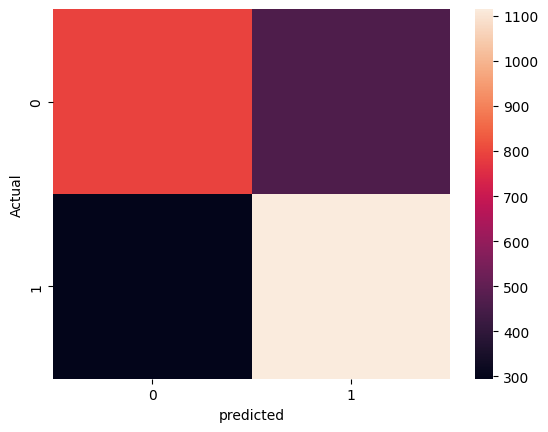

cv score 0.7451741321411959
______________________________________________________________________
KNeighborsClassifier()
accuracy_score:  0.718304576144036
classification report:                precision    recall  f1-score   support

           0       0.72      0.67      0.69      1256
           1       0.72      0.76      0.74      1410

    accuracy                           0.72      2666
   macro avg       0.72      0.72      0.72      2666
weighted avg       0.72      0.72      0.72      2666



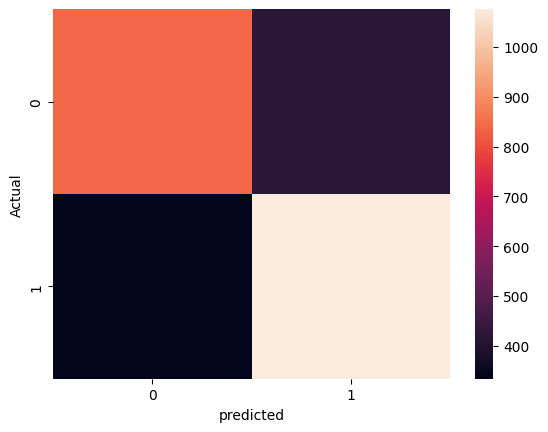

cv score 0.7301005260943214
______________________________________________________________________
SVC()
accuracy_score:  0.7231807951987997
classification report:                precision    recall  f1-score   support

           0       0.81      0.54      0.65      1256
           1       0.68      0.89      0.77      1410

    accuracy                           0.72      2666
   macro avg       0.75      0.71      0.71      2666
weighted avg       0.74      0.72      0.71      2666



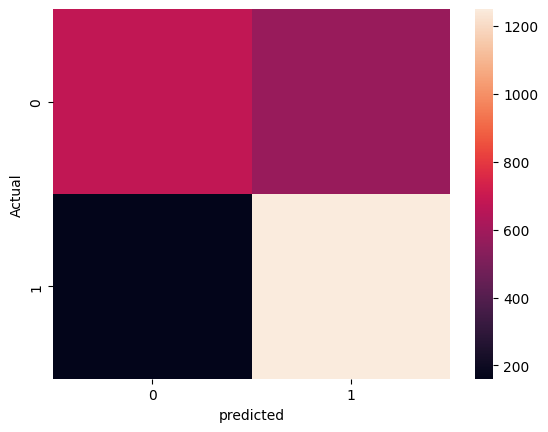

cv score 0.7647317402926193
______________________________________________________________________
RandomForestClassifier()
accuracy_score:  0.7288072018004501
classification report:                precision    recall  f1-score   support

           0       0.75      0.64      0.69      1256
           1       0.72      0.81      0.76      1410

    accuracy                           0.73      2666
   macro avg       0.73      0.72      0.72      2666
weighted avg       0.73      0.73      0.73      2666



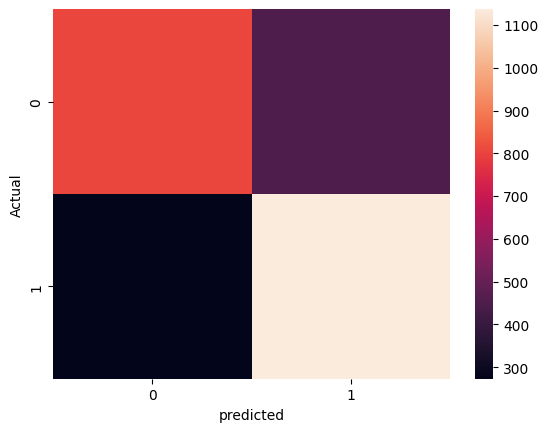

cv score 0.7668266867482757
______________________________________________________________________


In [80]:
par_dt={'max_depth':[5,10,15,20],
        'min_samples_split':[2,5,10],
        'min_samples_leaf':[1,2,5],
        'criterion':['gini','entropy']
        }

par_kn={'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
        }

par_svc={'C':[0.1,1,10,100],
         'kernel':['rbf'],
         'gamma':[1,0.1,0.01,0.0001]
         }

par_ran={'n_estimators':[50,100,200],
         'max_features':['sqrt','log2',None],
         'max_depth':[5,10]
         }


model={DecisionTreeClassifier():par_dt,KNeighborsClassifier():par_kn,SVC():par_svc,RandomForestClassifier():par_ran}

for i in model.keys():
  print(i)
  grid=GridSearchCV(i,model[i],cv=5,scoring='f1',n_jobs=-1)
  grid.fit(x_train,y_train)
  y_pred=grid.predict(x_test)
  print('accuracy_score: ',accuracy_score(y_test,y_pred))
  print('classification report: ',classification_report(y_test,y_pred))
  sns.heatmap(confusion_matrix(y_test,y_pred))
  plt.xlabel('predicted')
  plt.ylabel('Actual')
  plt.show()
  print('cv score',sum(cross_val_score(grid,x_test,y_test,cv=5))/5)
  print('______________'*5)

# Predict status of currently Operating startups

train and prediction should have same category of region, funding rounds, funding, and category list

In [81]:
same={}
for i in ['category_list','region','funding_rounds','funding']:
  same[i]=[]
  for j in ml[i].unique():
    if j not in eval[i].unique():
      same[i].append(j)
print(same)

{'category_list': ['Self Development', 'Real Estate Investors', 'EDA Tools', 'Pervasive Computing', 'Senior Citizens', 'Racing', 'Speech Recognition', 'Smart Grid', 'Product Search', 'Physicians', 'Retirement', 'Subscription Businesses', 'Musicians'], 'region': ['Munster', 'MaroÃºli', 'Santander', 'Leamington Spa', 'Monroe', 'Vevey', 'Leganes', 'Konya', 'Spruce Grove', 'Farrington Gurney', 'Homburg', 'Sutton Coldfield', 'New Westminster', 'Marbella', 'Karlskrona', 'Dunfermline', 'Harrow On The Hill', 'Garbsen', 'Herzogenaurach', 'CÃ¡ceres', 'Fyshwick', 'HRV - Other', 'BLM - Other', 'SOM - Other', 'Danderyd', 'Ilford', 'Doncaster', 'Seychelles', 'Lymington', 'MAF - Other', 'Muenchen'], 'funding_rounds': [], 'funding': ['High_B']}


In [82]:
same.keys()

dict_keys(['category_list', 'region', 'funding_rounds', 'funding'])

In [83]:
cat=~eval['category_list'].isin(same['category_list'])
reg=~eval['region'].isin(same['region'])
fr=~eval['funding_rounds'].isin(same['funding_rounds'])
fun=~eval['funding'].isin(same['funding'])

prediction=eval.loc[cat&reg&fr&fun]

In [84]:
prediction
prediction=prediction[['funding_rounds','funding','category_encoded','region_encoded','funding_year_encoded']]

scaling

In [85]:
prediction[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']]=mn.transform(prediction[['funding_rounds','category_encoded','region_encoded','funding_year_encoded']])

one hot encode

In [86]:
encoded_prediction=one.transform(prediction[['funding']])
prediction_df=pd.DataFrame(encoded_prediction,index=prediction.index,columns=one.get_feature_names_out(['funding']))

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [87]:
prediction

,funding_rounds,funding,category_encoded,region_encoded,funding_year_encoded
0,0.000000,Low_A,0.406250,0.464286,0.135025
1,0.058824,Low_A,0.236364,NaN,0.452354
2,0.000000,Low_A,0.338095,0.186425,0.452354
3,0.000000,Low_A,0.446667,0.692308,0.528608
4,0.000000,High_A,0.645963,0.333333,0.452354
...,...,...,...,...,...
66363,0.000000,Low_A,0.768392,0.692308,0.518745
66364,0.176471,Low_A,0.613559,NaN,0.518745
66365,0.000000,High_A,0.122468,0.186425,0.452354
66366,0.000000,Low_A,0.600000,0.678815,0.135025


In [88]:
prediction=prediction.drop(columns='funding')
prediction = pd.concat([prediction, prediction_df], axis=1)
prediction

,funding_rounds,category_encoded,region_encoded,funding_year_encoded,funding_High_B,funding_Low_A
0,0.000000,0.406250,0.464286,0.135025,0.0,1.0
1,0.058824,0.236364,NaN,0.452354,0.0,1.0
2,0.000000,0.338095,0.186425,0.452354,0.0,1.0
3,0.000000,0.446667,0.692308,0.528608,0.0,1.0
4,0.000000,0.645963,0.333333,0.452354,0.0,0.0
...,...,...,...,...,...,...
66363,0.000000,0.768392,0.692308,0.518745,0.0,1.0
66364,0.176471,0.613559,NaN,0.518745,0.0,1.0
66365,0.000000,0.122468,0.186425,0.452354,0.0,0.0
66366,0.000000,0.600000,0.678815,0.135025,0.0,1.0


In [89]:
par_svc={'C':[0.1,1,10,100],
         'kernel':['rbf'],
         'gamma':[1,0.1,0.01,0.0001]
         }

In [90]:
final=GridSearchCV(SVC(),par_svc,cv=5,scoring='f1',n_jobs=-1)
final.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.0001], 'kernel': ['rbf']},
             scoring='f1')

In [91]:
y_predict=final.predict([[0.000000,0.392857,0.520000,0.141640,0.0,1.0]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [92]:
y_predict

array([0])

In [93]:
lbl.inverse_transform([0])

array(['failed'], dtype=object)

In [94]:
final.best_estimator_.predict([[0.000000,0.392857,0.520000,0.141640,0.0,1.0]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(final.best_estimator_, f)

In [ ]:
path='/content/drive/MyDrive/ML_Practice/Business_analyst/startup/model.pkl'
import joblib

joblib.dump(grid.best_estimator_, path)

In [ ]:
from google.colab import files

files.download('model.pkl')